# Filtrado no lineal
En este experimento vamos a utilizar dos métodos de filtrado no lineal para intentar filtrar la linea de base de la señal ECG

In [40]:
import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.interpolate as spi
from itertools import takewhile



In [41]:
sio.whosmat("ECG_TP4.mat")
mat_struct = sio.loadmat("ECG_TP4.mat")

ecg_one_lead = mat_struct["ecg_lead"]
ecg_one_lead = ecg_one_lead.flatten()

qrs_detections = mat_struct["qrs_detections"]


In [42]:
fs = 1000  # Hz
nyq_frec = fs / 2

N = len(ecg_one_lead)

df_p = fs / N

# Método de estimación de línea de base a través de interpolaci´n de puntos especif´cos

Para este método utilizaremos ciertos puntos de interes (donde la actividad eléctrica cardíaca es nula) para interpolar la ínea de base y sustraerla de nuestra señal. Cabe destacar que para este método es necesario tener conocimientos sobre nuestra señal.

In [43]:

ms = 75
s = ms / 1000
offset = int(s * fs)

slice_of_detections = list(takewhile(lambda x: x <= N, qrs_detections))

puntos_de_interes = [int(m[0]) - offset for m in slice_of_detections]

# Puntos de interés
El siguiente gráfico muestra la estimación del nivel isoeléctrico a lo alrgo de toda nuestra señal

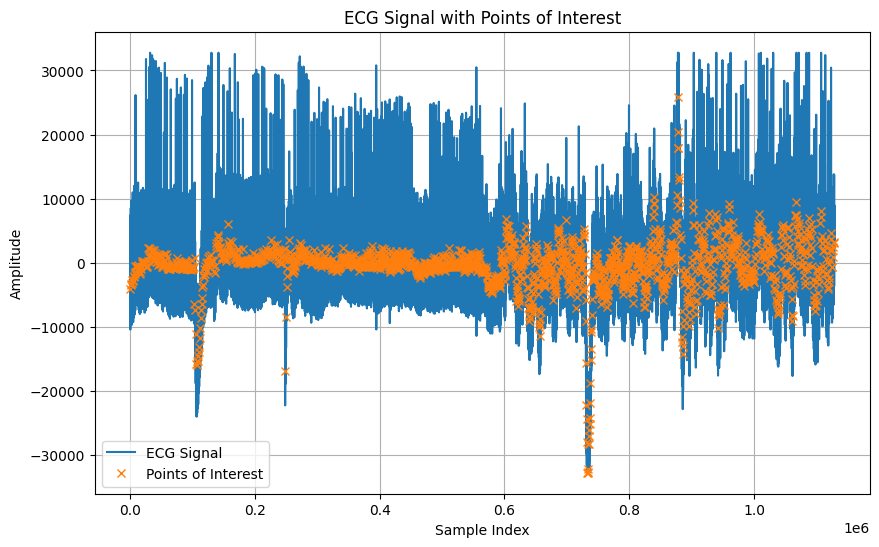

In [44]:
puntos_de_interes = [int(m[0]) - offset for m in qrs_detections]
plt.figure(figsize=(10, 6))
plt.plot(ecg_one_lead, label='ECG Signal')

plt.plot(puntos_de_interes, ecg_one_lead[puntos_de_interes], 'x', label='Points of Interest')

# Adding labels and legend
plt.title('ECG Signal with Points of Interest')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

Para observarlo en mas detalle veremos una zona especifica de la señal

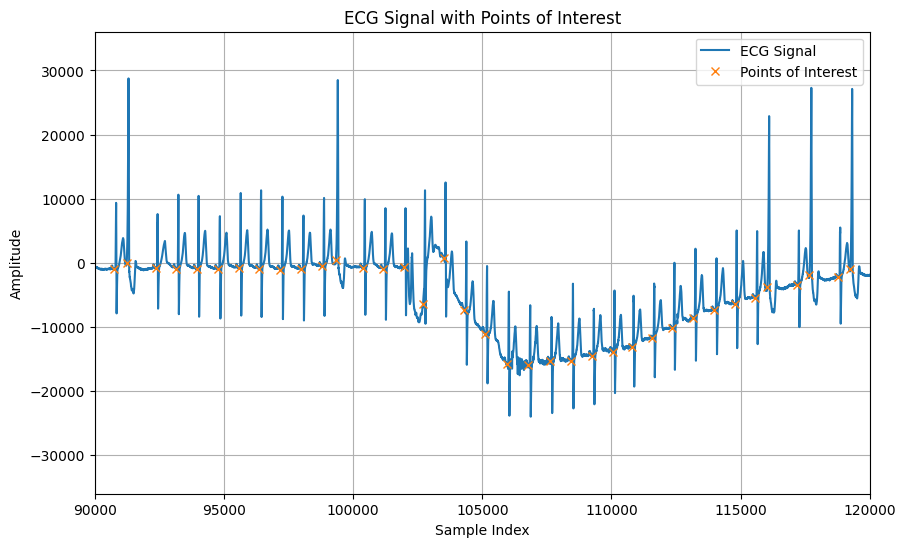

In [61]:
plt.figure(figsize=(10, 6))
plt.plot(ecg_one_lead, label='ECG Signal')

plt.plot(puntos_de_interes, ecg_one_lead[puntos_de_interes], 'x', label='Points of Interest')

# Adding labels and legend
plt.title('ECG Signal with Points of Interest')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.xlim(90000,120000 )

plt.show()


# Interpolación
Una vez obtenidos los puntos realizamos una interpolación cúbica para obtener la línea de base

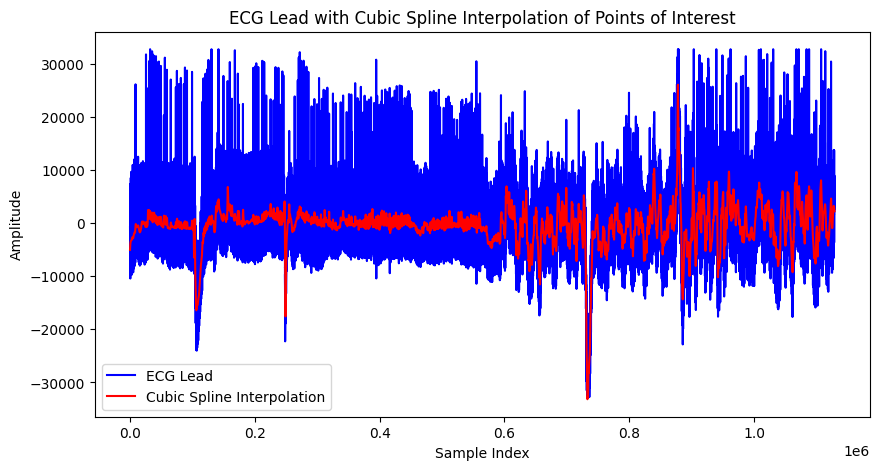

In [62]:
amplitudes_of_interest = ecg_one_lead[puntos_de_interes]
cs = spi.CubicSpline(puntos_de_interes, amplitudes_of_interest)


x = np.linspace(0, N -1, N)
noise_interpolated = cs(x)

plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead, label="ECG Lead", color="blue")
plt.plot(x, noise_interpolated, label="Cubic Spline Interpolation", color="red")
#plt.scatter(puntos_de_interes, amplitudes_of_interest, color="green", label="Points of Interest", zorder=5, marker='x')
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("ECG Lead with Cubic Spline Interpolation of Points of Interest")
plt.show()

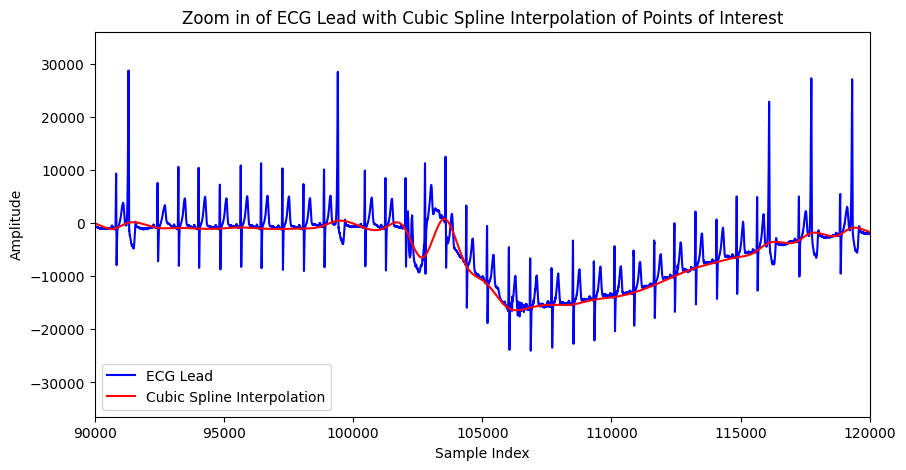

In [64]:
plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead, label="ECG Lead", color="blue")
plt.plot(x, noise_interpolated, label="Cubic Spline Interpolation", color="red")
#plt.scatter(puntos_de_interes, amplitudes_of_interest, color="green", label="Points of Interest", zorder=5, marker='x')
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("Zoom in of ECG Lead with Cubic Spline Interpolation of Points of Interest")
plt.xlim(90000,120000 )

plt.show()

# Filtrado
Para realizar el filtrado simplemente sustraemos la línea de base de la señal. Podemos observar en el gráfico como el filtro actuó sobre las áreas mas afectadas.

In [65]:
filtered_signal = ecg_one_lead - noise_interpolated

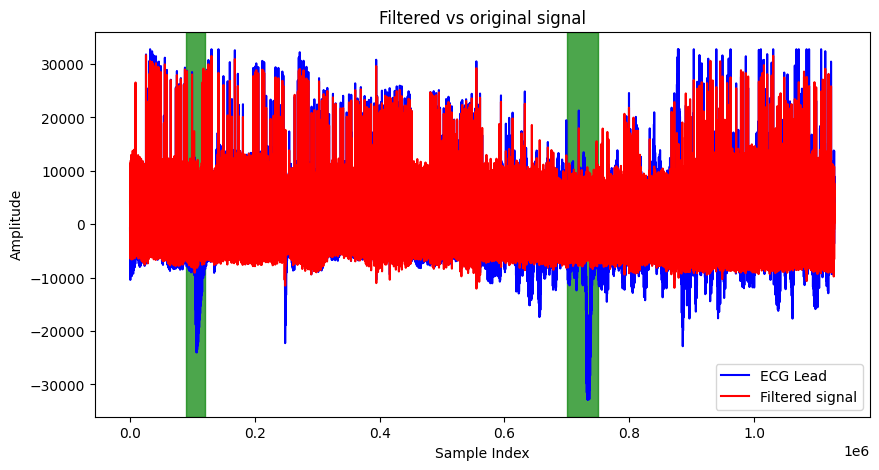

In [68]:
plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead, label="ECG Lead", color="blue")
plt.plot(filtered_signal, label="Filtered signal", color="red")
#plt.scatter(puntos_de_interes, amplitudes_of_interest, color="green", label="Points of Interest", zorder=5, marker='x')
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("Filtered vs original signal")
plt.axvspan(90000, 120000, color='green', alpha=0.7)  # Shaded region
plt.axvspan(700000, 750000, color='green', alpha=0.7)  # Shaded region

plt.show()

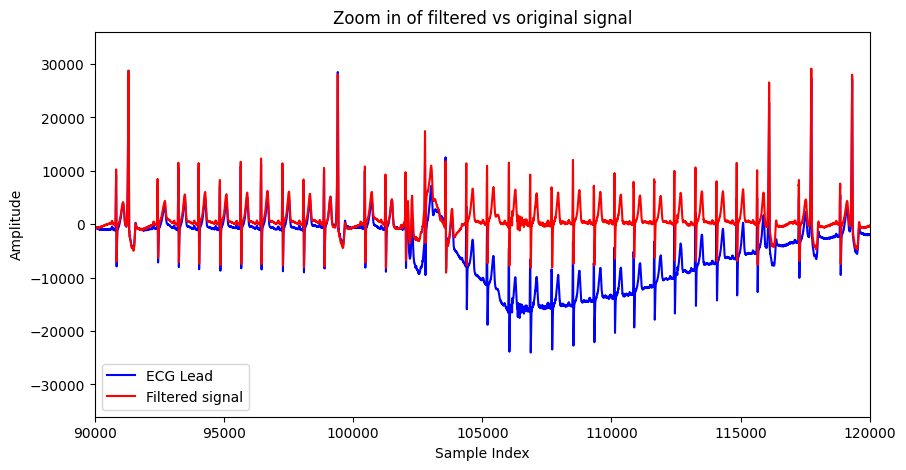

In [69]:
plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead, label="ECG Lead", color="blue")
plt.plot(filtered_signal, label="Filtered signal", color="red")
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("Zoom in of filtered vs original signal")
plt.xlim(90000,120000 )
plt.show()


# PSD
Vamos a analizar que sucedió con el espectro de potencia de la señal

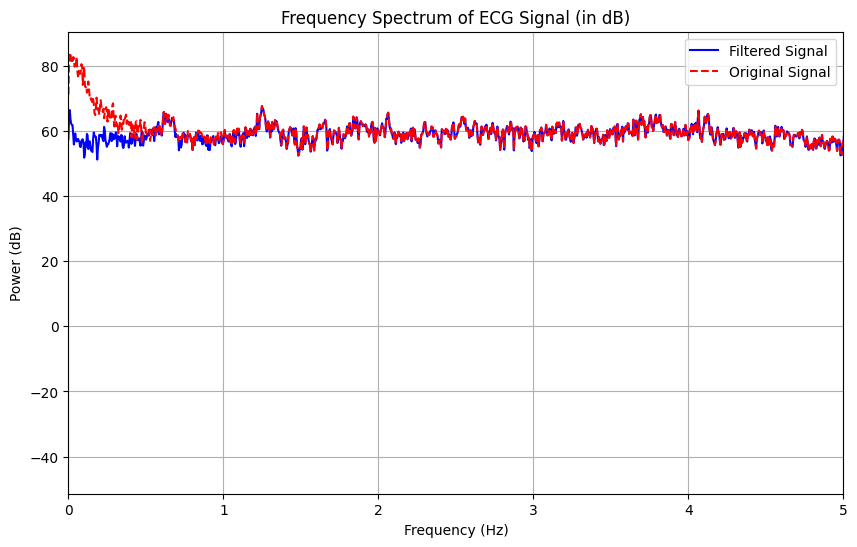

In [71]:

w = 5
f, p = sig.welch(ecg_one_lead, fs=1000, nperseg=N//w)
f, p_filt = sig.welch(filtered_signal, fs=1000, nperseg=N//w)

# Convert PSD to dB
p_db = 10 * np.log10(p)
p_filt_db = 10 * np.log10(p_filt)

# Plotting the frequency spectrum in dB (only positive frequencies)
plt.figure(figsize=(10, 6))
plt.plot(f, p_filt_db, label='Filtered Signal', color='blue')
plt.plot(f, p_db, label='Original Signal', color='red', linestyle='--')
plt.title('Frequency Spectrum of ECG Signal (in dB)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB)')
plt.xlim(0,5)
plt.grid()
plt.legend()
plt.show()

En este último gráfico podemos ver como la energía a frecuencias bajas disminuyo, producto de eliminar la linea de base que es una interferencia de muy baja frecuencia.

# Filtro de mediana
El filtro reemplaza cada valor  con la mediana de los valores dentro de una ventana deslizante centrada en ese punto. La mediana es el valor medio de un conjunto ordenado, lo que significa que está menos influenciada por valores extremos que el promedio.
Utilizaremos dos ventanas, 200 y 600 muestras para poder filtrar deflexiones de hasta 100 y 300 ms respectivamente.

Por su complejidad computacional, el filtro de mediana sera evaluado solo en un fragmento de la señal (buscaremos uno que este afectado para observar adecuadamente el funcionamiento del filtro)


In [86]:
N = 2000000
ecg_one_lead_10 = ecg_one_lead[600000:6000000+N]

In [87]:
filtered_median_signal_200 = sig.medfilt(ecg_one_lead_10, 201)
filtered_median_signal_600 = sig.medfilt(filtered_median_signal_200, 601)
filtered_signal = ecg_one_lead_10 - filtered_median_signal_600

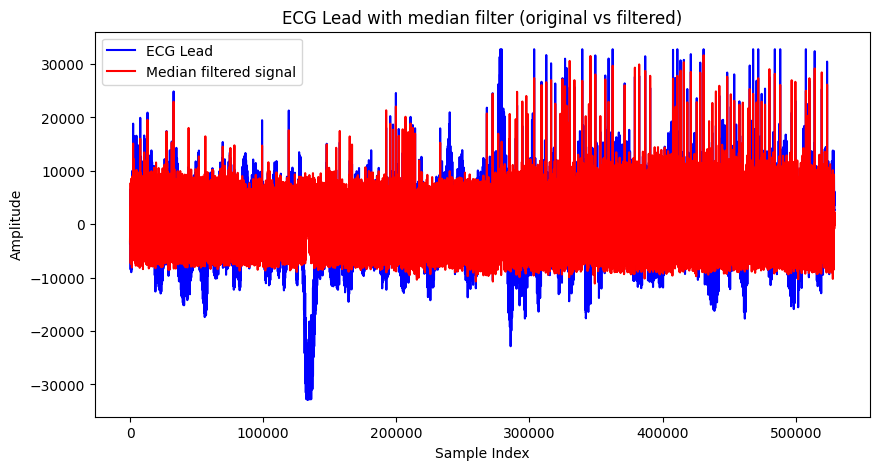

In [88]:

plt.figure(figsize=(10, 5))
plt.plot(ecg_one_lead_10, label="ECG Lead", color="blue")
plt.plot(filtered_signal, label="Median filtered signal", color="red")
#plt.scatter(puntos_de_interes, amplitudes_of_interest, color="green", label="Points of Interest", zorder=5, marker='x')
plt.legend()
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("ECG Lead with median filter (original vs filtered)")
plt.show()

/opt/anaconda3/envs/pds/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 1000000 is greater than input length  = 529116, using nperseg = 529116
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


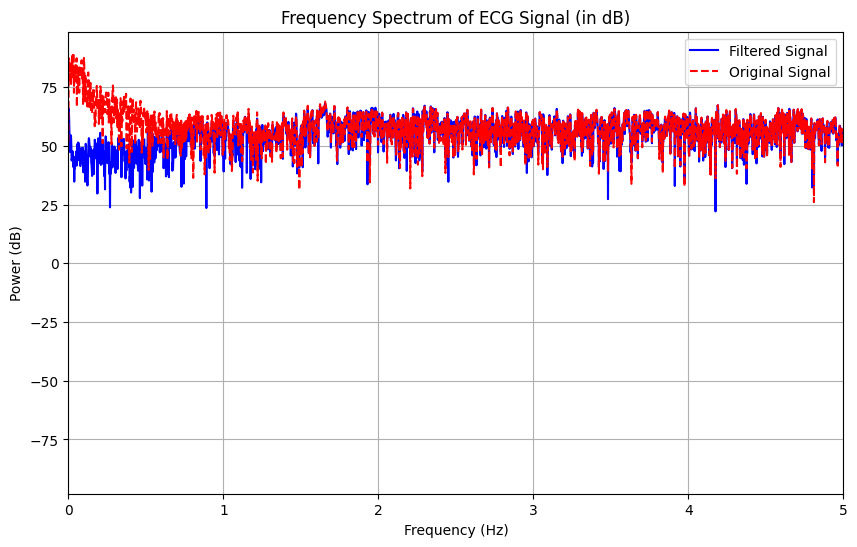

In [89]:

w = 5
f, p = sig.welch(ecg_one_lead_10, fs=1000, nperseg=N//2)
f, p_filt = sig.welch(filtered_signal, fs=1000, nperseg=N//2)

# Convert PSD to dB
p_db = 10 * np.log10(p)
p_filt_db = 10 * np.log10(p_filt)

# Plotting the frequency spectrum in dB (only positive frequencies)
plt.figure(figsize=(10, 6))
plt.plot(f, p_filt_db, label='Filtered Signal', color='blue')
plt.plot(f, p_db, label='Original Signal', color='red', linestyle='--')
plt.title('Frequency Spectrum of ECG Signal (in dB)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB)')
plt.xlim(0,5)
plt.grid()
plt.legend()
plt.show()

Podemos observar nuevamente en el espectro como el filtro de medianas elimino las componentes no deseadas en baja frecuencia